# Exercise 4 — Audio Classification
### Quran Reciter Identifier

---

## The Problem

An Islamic studies platform wants to automatically identify which Quran reciter
is speaking in an audio clip, to help users find recordings by their preferred reciter.

You are given a dataset of short audio recordings labeled by reciter.
Build a classifier that identifies the reciter from the audio alone.

---

## The Data

```python
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mohammedalrajeh/quran-recitations-for-audio-classification")
```

A CSV file (`files_paths.csv`) maps audio file paths to reciter labels.
Audio files are `.wav` format stored in subdirectories.

⚠️ **This modality was not given to you in the lectures.**
You need to figure out how to turn audio into something a neural network can process.
That is part of the exercise. Start here: `pip install librosa`

---

## What You Need to Deliver

A working Colab notebook that contains:

1. **A trained PyTorch model** that identifies the Quran reciter from an audio clip
2. **A brief written explanation** (in a markdown cell) of how you converted
   audio into a format the model could process — what did you use and why
3. **A training report** — loss and accuracy curves for train and validation
4. **A test accuracy score**
5. **A live inference demo** — given an audio file path, the model returns the predicted reciter

The model architecture and the full pipeline are yours to design.

---

In [1]:
!git clone https://github.com/Ibraheem-Al-hafith/classification_hub.git
%cd classification_hub

/content/classification_hub


In [2]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from tqdm import tqdm
from IPython.display import Audio
def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    print(f"Random seed set to: {seed}")

class config:
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"
    batch_size = 32 # This batch_size is not directly used by dataloader_configs
    num_workers = 2
    learning_rate = 0.001
    num_epochs = 2
    dataset_name = "mohammedalrajeh/quran-recitations-for-audio-classification"
    scaler = "standard" # options: "standard" , "minmax" , "robust"
    dataloader_configs = {
        "batch_size": 32, # Reduced batch size to mitigate OutOfMemoryError
        "num_workers": 2,
        "pin_memory": True,
        "prefetch_factor": 2,
        #"persistent_workers": True,
    }
    duration = 5 #choosed from EDA
    sr = 16000 # choosed from EDA
    image_shape = (284, 284)
    cache_dir = "cache"

seed_everything(config.seed)
print(f"Device set to: {config.device}")

Random seed set to: 42
Device set to: cuda


In [3]:
from utilities import download_kaggle_dataset
images_path = download_kaggle_dataset(config.dataset_name)

Using Colab cache for faster access to the 'quran-recitations-for-audio-classification' dataset.
Path to the dataset: /kaggle/input/quran-recitations-for-audio-classification
Is the path a file? False
Files inside the path: ['Dataset', 'files_paths.csv']


In [4]:
metadata = pd.read_csv(images_path + "/files_paths.csv")
metadata.FilePath = metadata.FilePath.apply(lambda x: Path(images_path) / "Dataset" / x)
id2label = {idx: label for idx, label in enumerate(metadata.Class.unique())}
label2id = {label: idx for idx, label in id2label.items()}
metadata.head()

,FilePath,Class
0,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan
1,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan
2,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan
3,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan
4,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan


In [5]:
import torchaudio
audio, sr = torchaudio.load(metadata.FilePath[np.random.randint(0,len(metadata))])
print(audio.shape, sr)
Audio(audio, rate=sr)

torch.Size([1, 240000]) 48000


In [6]:
resampler = torchaudio.transforms.Resample(sr, 16000)
resampled = resampler(audio)
Audio(resampled, rate=16000)

# We need to extract more information about audio data to determine the approperiate sr and duration :

In [7]:
def extract_metadata(file_path):
    audio, sr = torchaudio.load(file_path)
    duration = audio.shape[1] / sr
    return sr, duration

metadata['sr'], metadata['duration'] = zip(*metadata['FilePath'].apply(extract_metadata))
metadata.head()

,FilePath,Class,sr,duration
0,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan,48000,2.5
1,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan,48000,2.5
2,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan,48000,2.5
3,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan,48000,2.5
4,/kaggle/input/quran-recitations-for-audio-clas...,Mohammed_Aluhaidan,48000,2.5


# EDA

## Goals:
* to discover the approperiate duration and sample rate.

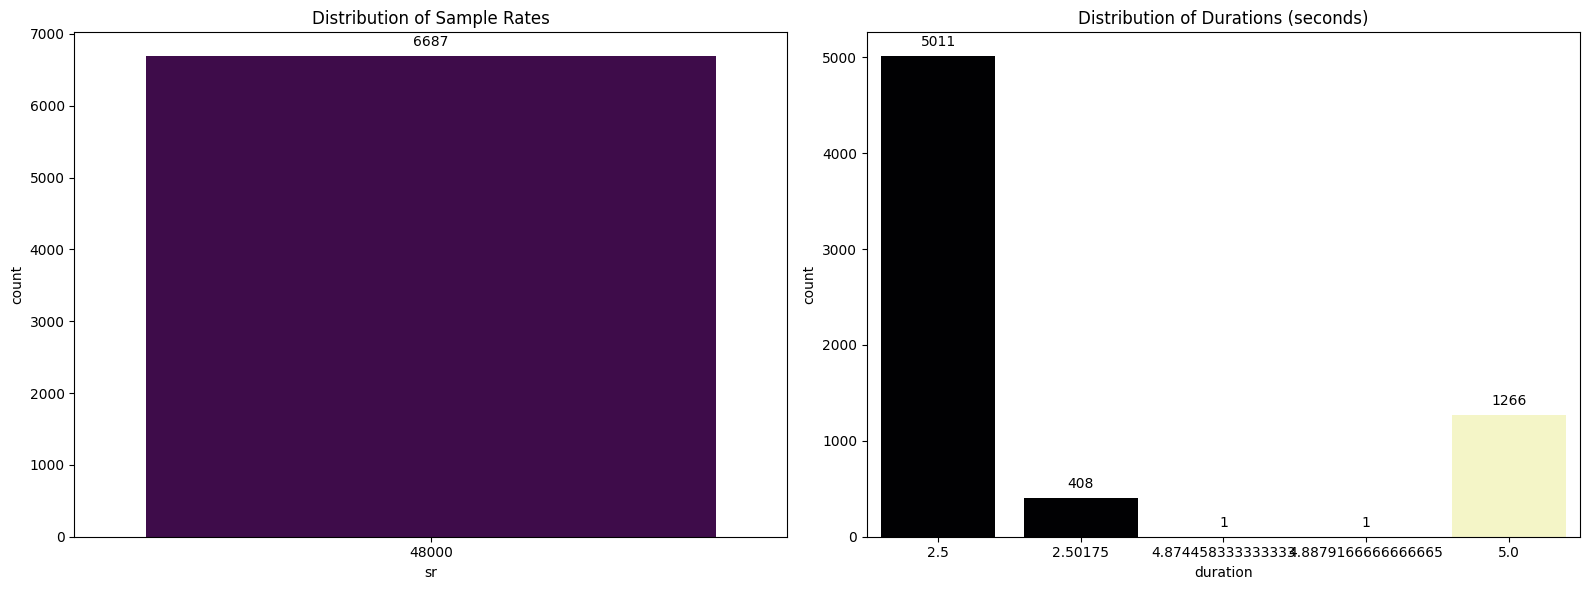

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot for Sample Rate (sr)
sns.countplot(data=metadata, x='sr', ax=axes[0], palette='viridis', hue='sr', legend=False)
axes[0].set_title('Distribution of Sample Rates')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Plot for Duration
sns.countplot(data=metadata, x='duration', ax=axes[1], palette='magma', hue='duration', legend=False)
axes[1].set_title('Distribution of Durations (seconds)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

Choosing duration=5 is a reasonable choice, and since we work on reciters audio, resampling to 16khz provide us a computation cost reduction without information loss(16khz is standard human hearing, and since we can detect the reciters directly by hearning its voice, we can safely build such a model).

In [11]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset
import pandas as pd
from tqdm import tqdm
import hashlib

class AudioMetaDataset(Dataset):
    """
    A unified PyTorch Dataset capable of feeding 1D waveforms (Wav2Vec2)
    and 2D time-frequency structures (CNN Spectrograms) natively, with
    high-performance disk caching to eliminate CPU processing bottlenecks.
    """
    def __init__(
        self,
        df: pd.DataFrame,
        target_sample_rate: int = config.sr,
        target_duration_sec: float = config.duration,
        image_shape: tuple[int, int]| None = None,
        transform = None,
        cache_dir: str | None = None,
        preload: bool = False
    ):
        """
        Args:
            df (pd.DataFrame): Dataframe containing 'FilePath' and 'Class' columns.
            target_sample_rate (int): Frequency to resample all incoming signals to.
            target_duration_sec (float): Fixed clip window length in seconds.
            image_shape (tuple, optional): Target (Height, Width) to reshape into 2D maps.
                                          If None, leaves signal formatted as a 1D tensor.
            transform (callable, optional): Custom transform function or HuggingFace processor.
            cache_dir (str, optional): Directory path to save preprocessed tensors. If None, caching is disabled.
            preload (bool): If True and cache_dir is provided, runs preprocessing sequentially
                            at initialization over the dataset.
        """
        self.df = df.reset_index(drop=True)
        self.target_sample_rate = target_sample_rate
        self.target_length = int(target_sample_rate * target_duration_sec)
        self.image_shape = image_shape
        self.transform = transform

        self.cache_dir = cache_dir
        if self.cache_dir:
            os.makedirs(self.cache_dir, exist_ok=True)

        # Internal standard 2D feature extractor if an image target shape is requested
        if self.image_shape:
            self.mel_spectrogram = T.MelSpectrogram(
                sample_rate=self.target_sample_rate,
                n_fft=2024,
                hop_length=512,
                n_mels=self.image_shape[0]
            )
            self.amplitude_to_db = T.AmplitudeToDB()

        if 'FilePath' not in df.columns or 'Class' not in df.columns:
            raise ValueError("Dataframe must contain 'FilePath' and 'Class' columns.")

        # Optional: Run a caching pass over all files during instantiation
        if preload and self.cache_dir:
            self._preload_cache()

    def __len__(self) -> int:
        return len(self.df)

    def _get_cache_path(self, file_path: str) -> str:
        """Generates a deterministic unique filename for the cached tensor file."""
        # Use an MD5 hash of the original absolute path to avoid deep or invalid nested subdirectories
        path_hash = hashlib.md5(os.path.abspath(file_path).encode('utf-8')).hexdigest()
        # Create a unique layout distinction depending on whether we cache 1D arrays or 2D spectrograms
        mode_suffix = f"2d_{self.image_shape[0]}x{self.image_shape[1]}" if self.image_shape else "1d"
        return os.path.join(self.cache_dir, f"{path_hash}_{mode_suffix}.pt")

    def _resample_if_necessary(self, waveform: torch.Tensor, sr: int) -> torch.Tensor:
        if sr != self.target_sample_rate:
            resampler = T.Resample(orig_freq=sr, new_freq=self.target_sample_rate)
            waveform = resampler(waveform)
        return waveform

    def _mix_down_to_mono(self, waveform: torch.Tensor) -> torch.Tensor:
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        return waveform

    def _adjust_length(self, waveform: torch.Tensor) -> torch.Tensor:
        num_channels, signal_length = waveform.shape

        if signal_length > self.target_length:
            waveform = waveform[:, :self.target_length]
        elif signal_length < self.target_length:
            missing_samples = self.target_length - signal_length
            padding = torch.zeros((num_channels, missing_samples), dtype=waveform.dtype)
            waveform = torch.cat([waveform, padding], dim=1)

        return waveform

    def _process_audio(self, file_path: str) -> torch.Tensor:
        """Core audio pipeline that transforms a raw .wav file into its clean tensor base."""
        waveform, sr = torchaudio.load(file_path)
        waveform = self._mix_down_to_mono(waveform)
        waveform = self._resample_if_necessary(waveform, sr)
        waveform = self._adjust_length(waveform)

        if self.image_shape:
            # Create the 2D Mel-Spectrogram map
            spectrogram = self.mel_spectrogram(waveform)
            spectrogram = self.amplitude_to_db(spectrogram)

            # Interpolate to match explicit canvas dimension targets
            spectrogram = F.interpolate(
                spectrogram.unsqueeze(0),
                size=self.image_shape,
                mode='bilinear',
                align_corners=False
            ).squeeze(0)
            return spectrogram
        else:
            # Return raw mono flattened tensor structure
            return waveform.squeeze(0)

    def _preload_cache(self):
        """Iterates over the dataset to ensure every item is calculated and written to disk upfront."""
        print(f"📦 Pre-populating audio tensor cache inside: {self.cache_dir}...")
        for idx in tqdm(range(len(self.df)), desc="Caching Tensors"):
            file_path = self.df.iloc[idx]['FilePath']
            cache_path = self._get_cache_path(file_path)
            if not os.path.exists(cache_path):
                try:
                    tensor = self._process_audio(file_path)
                    torch.save(tensor, cache_path)
                except Exception as e:
                    continue

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        file_path = row['FilePath']
        label = label2id[row['Class']]  # Maps standard string labels to integer ids

        # If cache directory is set, try loading straight from disk
        if self.cache_dir:
            cache_path = self._get_cache_path(file_path)
            if os.path.exists(cache_path):
                try:
                    tensor = torch.load(cache_path, weights_only=True)

                    # Apply volatile user/framework runtime transforms post-cache retrieval
                    if self.transform:
                        tensor = self.transform(tensor)

                    return tensor, torch.tensor(label, dtype=torch.long)
                except Exception as e:
                    print(f"WARNING: Cache corrupted for {file_path}, re-processing. Error: {e}")

        # Fallback or Lazy-Cache Strategy execution loop
        try:
            tensor = self._process_audio(file_path)

            # Save to disk lazily if caching is turned on but it wasn't preloaded
            if self.cache_dir:
                cache_path = self._get_cache_path(file_path)
                torch.save(tensor, cache_path)

            if self.transform:
                tensor = self.transform(tensor)

            return tensor, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            print(f"WARNING: Skipping unreadable file {file_path}. Reason: {e}")
            if self.image_shape:
                placeholder = torch.zeros((1, self.image_shape[0], self.image_shape[1]), dtype=torch.float32)
            else:
                placeholder = torch.zeros((self.target_length,), dtype=torch.float32)
            return placeholder, torch.tensor(label, dtype=torch.long)

In [12]:
import torch
from torchvision import datasets, transforms
def get_loaders(metadata, image_shape=None, train_transforms=None, test_transforms=None):
    train, test_val = train_test_split(metadata, test_size=0.4, random_state=config.seed, stratify=metadata.Class)
    val, test = train_test_split(test_val, test_size=0.5, random_state = config.seed, stratify=test_val.Class)

    train_dataset = AudioMetaDataset(train, image_shape=image_shape, transform=train_transforms, cache_dir=config.cache_dir+"/train", preload=True)
    val_dataset = AudioMetaDataset(val, image_shape=image_shape, transform=test_transforms, cache_dir=config.cache_dir+"/val", preload=True)
    test_dataset = AudioMetaDataset(test, image_shape=image_shape, transform=test_transforms, cache_dir=config.cache_dir+"/test", preload=True)

    train_loader = DataLoader(train_dataset, shuffle=True, **config.dataloader_configs)
    val_loader = DataLoader(val_dataset, shuffle=False, **config.dataloader_configs)
    test_loader = DataLoader(test_dataset, shuffle=False, **config.dataloader_configs)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_loaders(metadata, config.image_shape)


📦 Pre-populating audio tensor cache inside: cache/train...


Caching Tensors: 100%|██████████| 4012/4012 [00:00<00:00, 19194.48it/s]


📦 Pre-populating audio tensor cache inside: cache/val...


Caching Tensors: 100%|██████████| 1337/1337 [00:00<00:00, 20592.70it/s]


📦 Pre-populating audio tensor cache inside: cache/test...


Caching Tensors: 100%|██████████| 1338/1338 [00:00<00:00, 19651.51it/s]


In [13]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 1, 284, 284]) torch.Size([32])


In [14]:
import torchvision.models as models
import torch.nn as nn

# Initialize ResNet18 without pre-trained weights
model = models.resnet18(weights=None)

# Adjust the first layer for 1-channel (grayscale) mel-spectrograms
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Adjust the final fully connected layer for the number of reciters
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(id2label))

model = model.to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
print(f"Model initialized from scratch and moved to {config.device}")

Model initialized from scratch and moved to cuda


In [15]:
from utilities import Trainer, TrainerConfig

criterion = nn.CrossEntropyLoss()
train_config = TrainerConfig(epochs=10, task_type = "multi")

trainer = Trainer(
    model=model,
    config=train_config,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader
)

history = trainer.fit()

Starting pipeline on device: cuda (Task: multi)


Epoch [1/10] -> Train Loss: 1.0754 | Acc: 64.83% | F1: 0.6360 || Val Loss: 0.9218 | Acc: 70.83% | F1: 0.6844
🏆 Best validation loss updated to 0.9218. Model saved.


Epoch [2/10] -> Train Loss: 0.2448 | Acc: 92.80% | F1: 0.9261 || Val Loss: 0.2068 | Acc: 93.57% | F1: 0.9363
🏆 Best validation loss updated to 0.2068. Model saved.


Epoch [3/10] -> Train Loss: 0.1063 | Acc: 97.36% | F1: 0.9729 || Val Loss: 0.1062 | Acc: 97.38% | F1: 0.9725
🏆 Best validation loss updated to 0.1062. Model saved.


Epoch [4/10] -> Train Loss: 0.0617 | Acc: 98.35% | F1: 0.9832 || Val Loss: 0.0343 | Acc: 99.25% | F1: 0.9925
🏆 Best validation loss updated to 0.0343. Model saved.


...

Epoch [7/10] -> Train Loss: 0.0029 | Acc: 100.00% | F1: 1.0000 || Val Loss: 0.0094 | Acc: 99.70% | F1: 0.9968
🏆 Best validation loss updated to 0.0094. Model saved.


Epoch [8/10] -> Train Loss: 0.0021 | Acc: 100.00% | F1: 1.0000 || Val Loss: 0.0083 | Acc: 99.70% | F1: 0.9971
🏆 Best validation loss updated to 0.0083. Model saved.


Epoch [9/10] -> Train Loss: 0.0019 | Acc: 100.00% | F1: 1.0000 || Val Loss: 0.0084 | Acc: 99.70% | F1: 0.9968


Epoch [10/10] -> Train Loss: 0.0017 | Acc: 100.00% | F1: 1.0000 || Val Loss: 0.0094 | Acc: 99.63% | F1: 0.9961


{'train_loss': [1.0753508669547998,
  0.24483711651321186,
  0.10634018179188935,
  0.06166318837824396,
  0.022832262460680926,
  0.007324905664003561,
  0.0029171280969576847,
  0.002117522751470491,
  0.0019166049128375086,
  0.0017044301813789612],
 'val_loss': [0.9217867462066188,
  0.20683014589008683,
  0.10618159645526108,
  0.03426517165567595,
  0.0369308104518475,
  0.011420412681838002,
  0.009410252695361245,
  0.008343651232141765,
  0.008432825023507617,
  0.009375643577543696],
 'train_acc': [0.6483050847457628,
  0.9279661016949152,
  0.9735792622133599,
  0.9835493519441675,
  0.9957627118644068,
  0.9995014955134596,
  1.0,
  1.0,
  1.0,
  1.0],
 'val_acc': [0.7083021690351533,
  0.9356768885564697,
  0.9738219895287958,
  0.9925205684367988,
  0.9902767389678384,
  0.9985041136873598,
  0.9970082273747195,
  0.9970082273747195,
  0.9970082273747195,
  0.9962602842183994],
 'train_f1': [0.6360121642810573,
  0.9261109946695033,
  0.9728531911377356,
  0.9832020769780

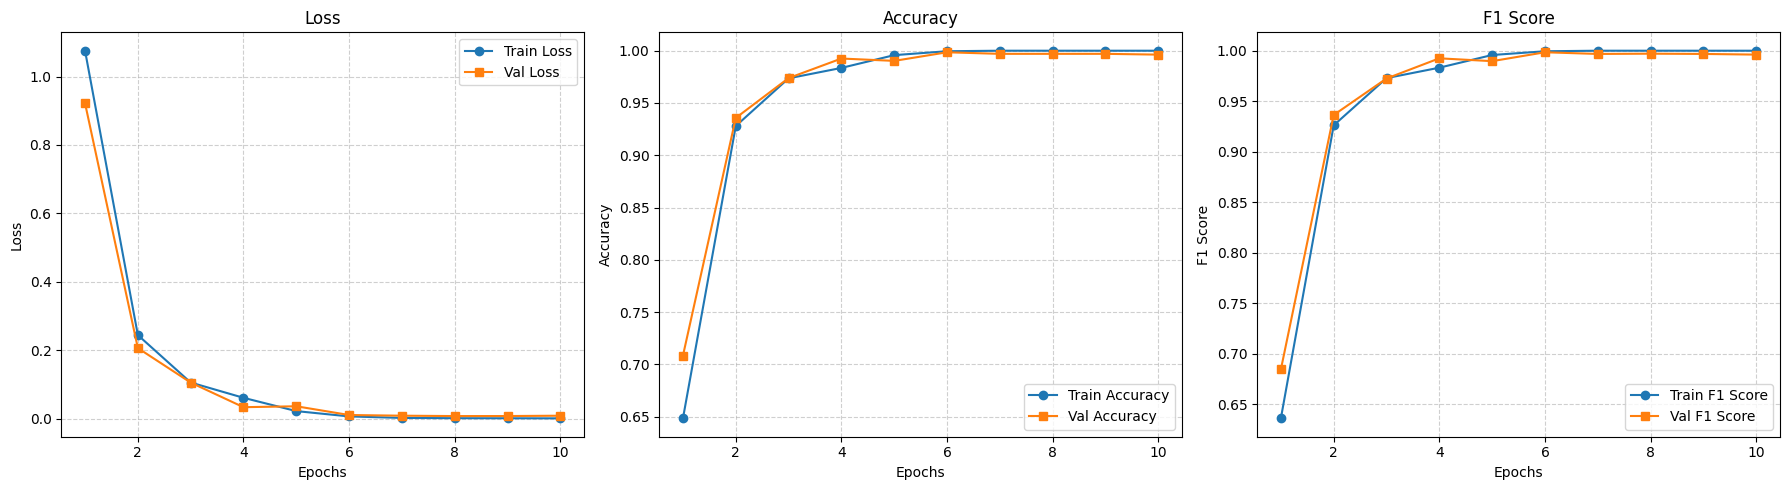

In [16]:
trainer.plot_metrics()

In [17]:
trainer.evaluate(test_loader)

(0.008238794128250425, 0.9977578475336323, 0.9976470082633756)

# Further questions :

* n_fft=1024 didn't work, n_fft=2024 does, why?

In [23]:
from transformers import Wav2Vec2Processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")

def wav2vec_transform(waveform_tensor):
    # waveform_tensor is loaded as [samples] from the fallback loop or disk cache
    speech_array = waveform_tensor.squeeze().numpy()

    # Process using Hugging Face's normalization matrix
    inputs = processor(speech_array, sampling_rate=16000, return_tensors="pt")
    return inputs.input_values.squeeze(0)

In [26]:
train_loader, val_loader, test_loader = get_loaders(metadata, None, wav2vec_transform, wav2vec_transform)

📦 Pre-populating audio tensor cache inside: cache/train...


Caching Tensors: 100%|██████████| 4012/4012 [01:39<00:00, 40.36it/s]


📦 Pre-populating audio tensor cache inside: cache/val...


Caching Tensors: 100%|██████████| 1337/1337 [00:41<00:00, 32.20it/s]


📦 Pre-populating audio tensor cache inside: cache/test...


Caching Tensors: 100%|██████████| 1338/1338 [00:30<00:00, 43.80it/s]


In [27]:
audios, labels = next(iter(train_loader))
print(audios.shape, labels.shape)

torch.Size([32, 80000]) torch.Size([32])


In [32]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2Config

def get_wav2vec2_classifier(num_classes: int = 3, strategy: str = "transfer_learning"):
    """
    Instantiates a Wav2Vec2 architecture for classification based on different training strategies.

    Strategies:
        'transfer_learning' : Freezes the base feature encoder, trains only the classification head.
        'fine_tuning'       : Keeps all weights trainable, optimized with a very low learning rate.
        'from_scratch'      : Randomly initializes all weights throughout the entire network.
    """
    model_id = "facebook/wav2vec2-base"

    if strategy in ["transfer_learning", "fine_tuning"]:
        print(f"🔹 Loading Pretrained weights via strategy: {strategy}...")
        model = Wav2Vec2ForSequenceClassification.from_pretrained(
            model_id,
            num_labels=num_classes,
            problem_type="single_label_classification"
        )

        if strategy == "transfer_learning":
            print("🔒 Freezing core Wav2Vec2 feature extractor layers...")
            # Freeze the convolutional feature extractor
            model.freeze_feature_encoder()
            # Alternatively, freeze the entire base transformer body if you only want the head trained:
            for name, param in model.wav2vec2.named_parameters():
                param.requires_grad = False

    elif strategy == "from_scratch":
        print("🏗️ Initializing model architecture completely from scratch (Random weights)...")
        # Load a configuration template without pulling down the massive weights binary
        config = Wav2Vec2Config.from_pretrained(model_id, num_labels=num_classes)
        config.problem_type = "single_label_classification"
        model = Wav2Vec2ForSequenceClassification(config)

    else:
        raise ValueError("Invalid strategy. Choose from 'transfer_learning', 'fine_tuning', 'from_scratch'.")

    return model

# If your trainer expects a raw tensor output, wrap the model call:
class HFModelWrapper(nn.Module):
    def __init__(self, hf_model):
        super().__init__()
        self.hf_model = hf_model
    def forward(self, x):
        return self.hf_model(x).logits


In [35]:
model = get_wav2vec2_classifier(num_classes=len(id2label), strategy="finetuning")
model = HFModelWrapper(model).to(config.device)

# Only optimize parameters tracking active gradients (the classification head)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=config.learning_rate)

🔹 Loading Pretrained weights via strategy: transfer_learning...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.bias               | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
classifier.weight            | MISSING    | 
projector.bias               | MISSING    | 
projector.weight             | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🔒 Freezing core Wav2Vec2 feature extractor layers...


In [36]:
from utilities import Trainer, TrainerConfig

criterion = nn.CrossEntropyLoss()
train_config = TrainerConfig(epochs=3, task_type = "multi")

trainer = Trainer(
    model=model,
    config=train_config,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader
)

history = trainer.fit()

Starting pipeline on device: cuda (Task: multi)


Epoch [1/3] -> Train Loss: 1.9139 | Acc: 37.89% | F1: 0.3513 || Val Loss: 1.7776 | Acc: 43.61% | F1: 0.3938
🏆 Best validation loss updated to 1.7776. Model saved.


KeyboardInterrupt: 